# King County House Sales

## Dataset

This dataset contains **21,613 house sales** in King County, Washington (which includes Seattle), between May 2014 and May 2015. The task is to predict the **sale price** of a house from its physical characteristics and condition.

| Feature | Description |
|---|---|
| `price` | **Target**: sale price in USD |
| `bedrooms` | Number of bedrooms |
| `bathrooms` | Number of bathrooms (fractional values possible) |
| `sqft_living` | Interior living area in square feet |
| `sqft_lot` | Lot area in square feet |
| `floors` | Number of floors |
| `waterfront` | 1 if the property overlooks a waterfront, 0 otherwise |
| `view` | Quality of view index (0–4) |
| `condition` | Overall condition index (1–5) |
| `grade` | Overall construction and design grade (1–13, based on King County grading system) |
| `sqft_above` | Square footage of the house excluding basement |
| `sqft_basement` | Square footage of the basement |
| `yr_built` | Year the house was built |
| `yr_renovated` | Year of last renovation (0 = never renovated) |
| `sqft_living15` | Interior living area of the 15 nearest neighbors (2015) |
| `sqft_lot15` | Lot area of the 15 nearest neighbors (2015) |
| `id` | House identifier — drop before modeling |
| `date` | Sale date — can be used to engineer month/season features |

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/kc_house_data.csv")

print(df.shape)

(21613, 18)


------------
-----------

# King County House Price Prediction

## Problem

Predict house sale prices using property features to understand the key drivers of home value.

## Why This Matters

Accurate price prediction helps:
- Buyers and sellers make informed decisions
- Real estate professionals price homes effectively
- Identify which features most impact property value

------------

## Dataset

- 21,613 house sales (King County, WA)
- Includes features like size, location, condition, and quality
- Target variable: **price**

--------
---------

## Load Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/kc_house_data.csv")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,1800,7503


Dataset loaded successfully with 21,613 observations and multiple property features.

-------

## Data Overview

**Purpose**  
Understand dataset structure, data types, and potential issues before analysis.

In [15]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  sqft_living15  21613 non-null  int64  
 17  sqft_lot15     21613 non-null  int64  
dtypes: flo

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,6210.000000,871200.000000


- Dataset contains both numerical and categorical features  
- No major missing data issues detected  
- Price shows high variance, indicating potential skewness  
---------------
----

## Exploritory Data Analysis

### Price Distribution

**Purpose**  
Understand how house prices are distributed and detect skewness or outliers.

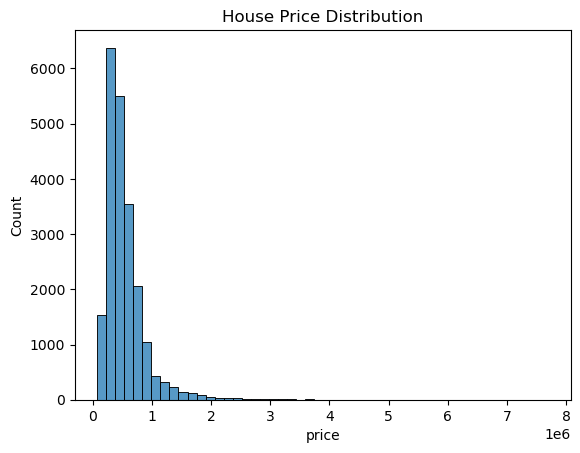

In [16]:
sns.histplot(df["price"], bins=50)
plt.title("House Price Distribution")
plt.show()

Price distribution is right-skewed, meaning most homes are mid-range with fewer high-value properties.

------

### Price vs Square Footage

**Purpose**  
Examine relationship between home size and price.

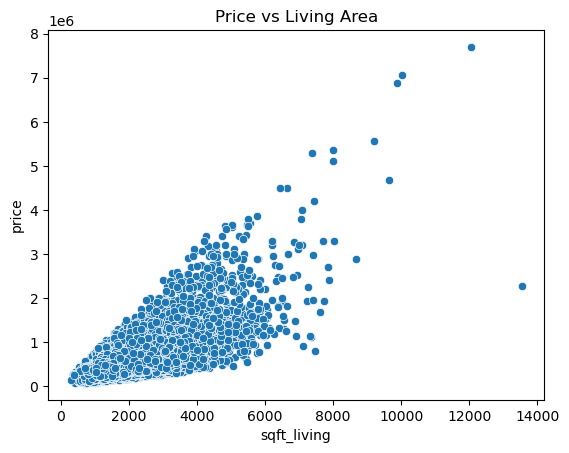

In [17]:
sns.scatterplot(x=df["sqft_living"], y=df["price"])
plt.title("Price vs Living Area")
plt.show()

Strong positive relationship indicates larger homes tend to have higher prices.

------

### Feature Correlation

**Purpose**  
Identify which features are most strongly related to price.

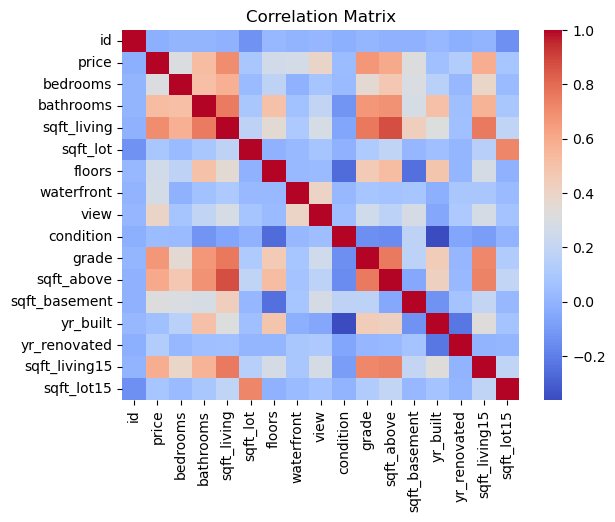

In [18]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

sqft_living, grade, and bathrooms show strong correlation with price.

-------
-------

## Data Preparation

**Purpose**  
Prepare the dataset for modeling by cleaning data, handling features, and selecting relevant variables.

### Feature Selection

**Purpose**  
Remove irrelevant or non-predictive features to improve model performance.

In [19]:
df = df.drop(columns=["id"])

The `id` column is a unique identifier and does not provide predictive value.

------

### Feature Engineering (Date)

**Purpose**  
Extract useful information from the date feature.

In [20]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df = df.drop(columns=["date"])

Converted date into year and month to capture time-based trends in pricing.

----

### Define Features and Target

**Purpose**  
Separate input variables from the target variable.

In [21]:
X = df.drop(columns=["price"])
y = df["price"]

Target variable is price, while all other features are used as predictors.

-----

### Train-Test Split

**Purpose**  
Split data to evaluate model performance on unseen data.

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

80% training, 20% testing ensures reliable model evaluation.

------
------

## Modeling

### Linear Regression

**Purpose**  
Establish a baseline model for predicting house prices.

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Linear Regression provides a baseline for evaluating more complex models.

----

## Model Evaluation

**Purpose**  
Measure how well the model predicts house prices.

In [25]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 228336.5589954041
R2 Score: 0.6551215898565291


### Model Interpretation

- The model achieves an RMSE of approximately 228,000, meaning predictions are typically off by about $228K. This relatively high error reflects the wide range and skewness of housing prices in the dataset.

- The R² score of ~0.65 indicates that the model explains about 65% of the variance in house prices, showing a solid baseline performance for a simple linear model.

- Overall, the model captures key pricing trends but lacks the ability to model more complex relationships, suggesting that more advanced models could further improve predictive accuracy.
--------
-------

## Conclusions

### Key Insights
- Square footage (sqft_living) is the strongest predictor of price
- Property grade and overall quality significantly impact value
- Price distribution is right-skewed with high-value outliers

-----------


### Model Performance
- RMSE: ~228,000 → average prediction error in USD
- R²: ~0.65 → model explains ~65% of price variation

--------

### Limitations
- Linear regression cannot capture complex relationships
- Outliers and skewness affect accuracy


-------


### Future Improvements
- Try Random Forest or Gradient Boosting
- Apply feature transformations (log(price))


----------


### Business Interpretation
- Model can estimate property value ranges based on features
- Useful for real estate pricing and investment decisions
- Highlights which features add the most value to a home


---------
------